# HW3 - CS503 - W24
## Department of Computer Science

#### Load libraies

In [1]:
import scipy.io
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from spectral import imshow, view_cube
from matplotlib import patches
from spectral import spy_colors
from spectral import imshow as spyShow
import tqdm
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

#### The names of the classes available in the HS image

In [2]:
class_names = ['Unknown', 'Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn'
                        ,'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed', 
                        'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill',
                        'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives',
                        'Stone-Steel-Towers']

#### 1. Load Hyperspectral image

In [3]:
X = scipy.io.loadmat('Indian_pines_corrected.mat')['indian_pines_corrected']

In [4]:
# shape of image 145x145x220
X.shape

(145, 145, 200)

#### 2. False color image uisng bands 30 as Red, 20 and Green and 10 as Blue

ImageView object:
  Display bands       :  (30, 20, 10)
  Interpolation       :  nearest
  RGB data limits     :
    R: [np.float64(2272.0), np.float64(6366.0)]
    G: [np.float64(2560.0), np.float64(7271.0)]
    B: [np.float64(2700.0), np.float64(7990.0)]

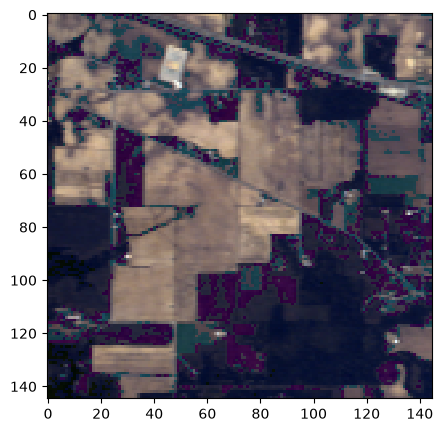

In [5]:
imshow(X, (30, 20, 10), figsize=(5, 5), interpolation='nearest')

#### 3. Load reference image (ground truth)

ImageView object:
  Interpolation       :  <default>

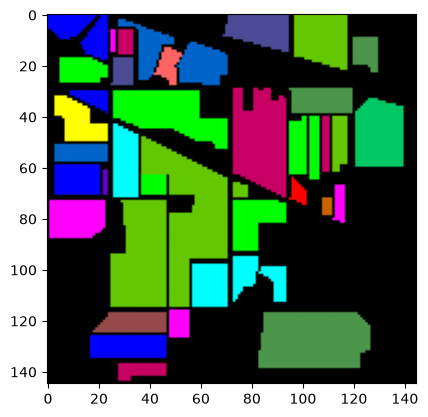

In [6]:
gt = scipy.io.loadmat('Indian_pines_gt.mat')['indian_pines_gt']
imshow(classes=gt)

In [7]:
# display class labels
np.unique(gt)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
      dtype=uint8)

#### 4. Class distribution 

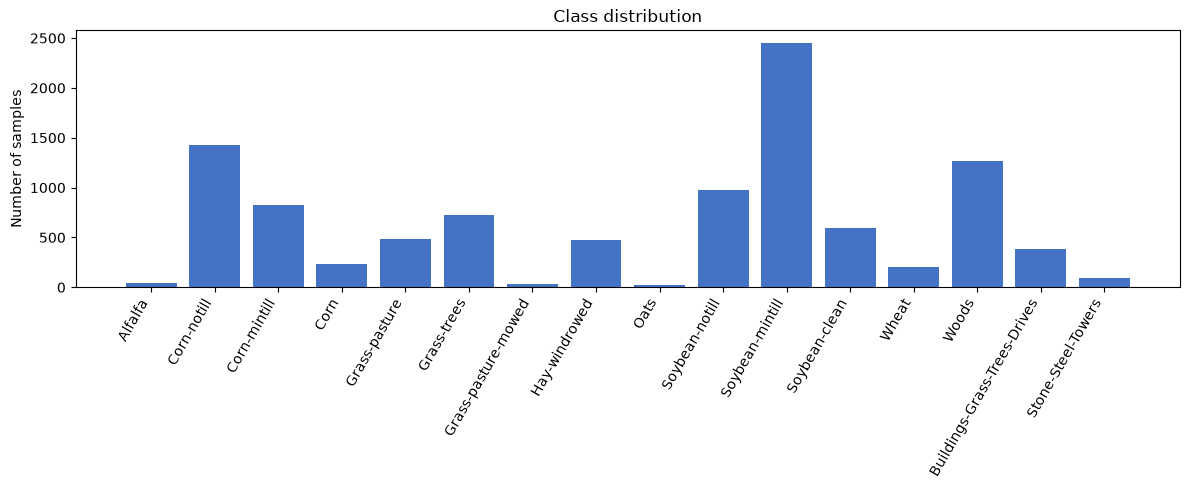

In [8]:
# Count the pixels of each class, dropping the background class (0)
unique, counts = np.unique(gt, return_counts=True)
keep = unique != 0
classes = unique[keep]
class_counts = counts[keep]
labels = [class_names[c] for c in classes]

plt.figure(figsize=(12, 5))
plt.bar(labels, class_counts, color="#4472C4")
plt.title("Class distribution")
plt.ylabel("Number of samples")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### 5. Overlaying the ground truth mask on the image

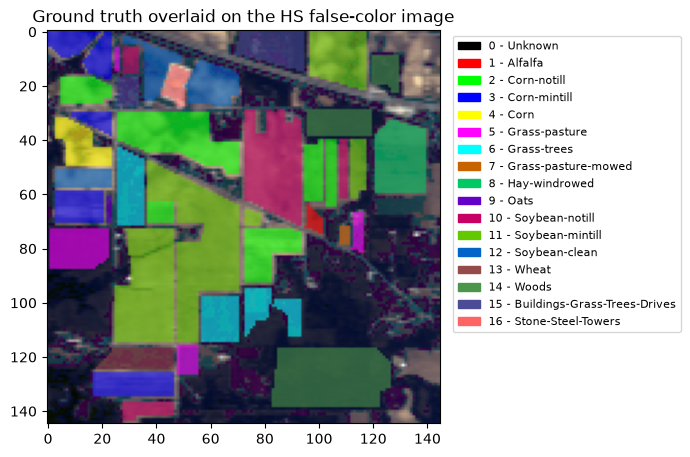

In [9]:
# False-color RGB background from bands 30/20/10, each stretched to [0, 1]
def stretch(band):
    b = band.astype(float)
    return (b - b.min()) / (b.max() - b.min() + 1e-9)

rgb = np.dstack([stretch(X[:, :, 30]), stretch(X[:, :, 20]), stretch(X[:, :, 10])])

# Class colours (spectral's default palette), overlaid where a label exists
colors = spy_colors / 255.0
overlay = colors[gt]
alpha = 0.6
blended = rgb.copy()
m = gt > 0
blended[m] = (1 - alpha) * rgb[m] + alpha * overlay[m]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(blended)
ax.set_title("Ground truth overlaid on the HS false-color image")

handles = [patches.Patch(color=colors[c], label=f"{c} - {class_names[c]}")
           for c in np.unique(gt)]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

#### 6.	Select 1% of samples from each class and plot their mean vectors. These mean vectors represent the mean spectral signatures of the classes.

In [10]:
# 1. Create a Python dcitionary for the class names 
# - key: class number
# - value: class name
class_names_a = np.array(class_names)
labels_dict = dict(zip(np.unique(gt), class_names))
unique, counts = np.unique(gt, return_counts=True)
labels_distribution = dict(zip(unique, counts))
labels_distribution

{np.uint8(0): np.int64(10776),
 np.uint8(1): np.int64(46),
 np.uint8(2): np.int64(1428),
 np.uint8(3): np.int64(830),
 np.uint8(4): np.int64(237),
 np.uint8(5): np.int64(483),
 np.uint8(6): np.int64(730),
 np.uint8(7): np.int64(28),
 np.uint8(8): np.int64(478),
 np.uint8(9): np.int64(20),
 np.uint8(10): np.int64(972),
 np.uint8(11): np.int64(2455),
 np.uint8(12): np.int64(593),
 np.uint8(13): np.int64(205),
 np.uint8(14): np.int64(1265),
 np.uint8(15): np.int64(386),
 np.uint8(16): np.int64(93)}

In [11]:
# Remove the background class (# 0)
labels_distribution.pop(0)
labels_distribution

{np.uint8(1): np.int64(46),
 np.uint8(2): np.int64(1428),
 np.uint8(3): np.int64(830),
 np.uint8(4): np.int64(237),
 np.uint8(5): np.int64(483),
 np.uint8(6): np.int64(730),
 np.uint8(7): np.int64(28),
 np.uint8(8): np.int64(478),
 np.uint8(9): np.int64(20),
 np.uint8(10): np.int64(972),
 np.uint8(11): np.int64(2455),
 np.uint8(12): np.int64(593),
 np.uint8(13): np.int64(205),
 np.uint8(14): np.int64(1265),
 np.uint8(15): np.int64(386),
 np.uint8(16): np.int64(93)}

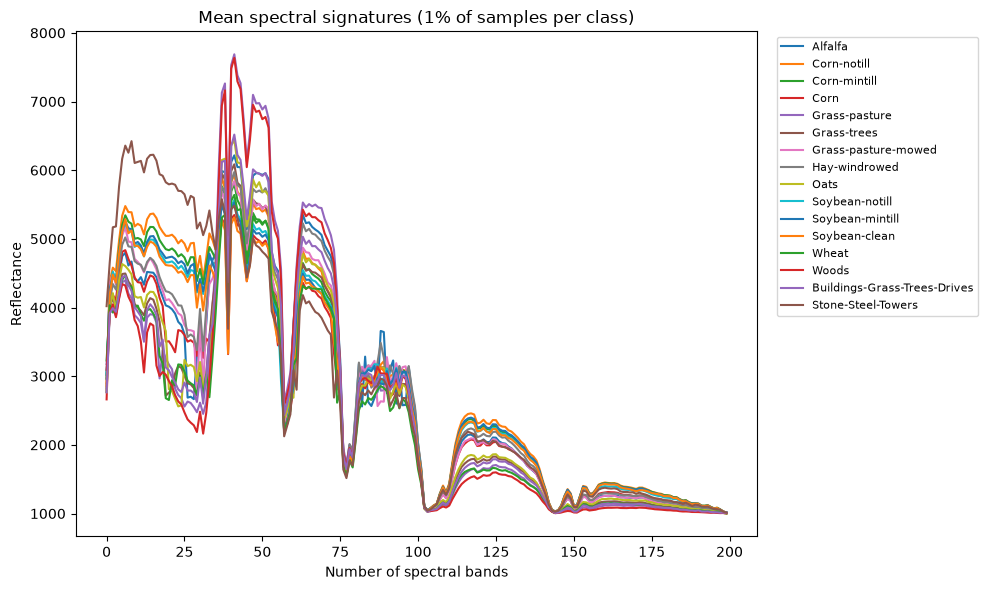

In [12]:
# For each class take 1% of its pixels at random and average their spectra
np.random.seed(42)

plt.figure(figsize=(10, 6))
for c in labels_distribution:                       # classes 1..16 (background already removed)
    coords = np.argwhere(gt == c)
    n_sel = max(1, int(0.01 * len(coords)))
    chosen = coords[np.random.choice(len(coords), n_sel, replace=False)]
    spectra = X[chosen[:, 0], chosen[:, 1], :]
    mean_signature = spectra.mean(axis=0)
    plt.plot(mean_signature, label=class_names[c])

plt.xlabel("Number of spectral bands")
plt.ylabel("Reflectance")
plt.title("Mean spectral signatures (1% of samples per class)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

#### 7.1. Apply PCA on the data cube and display the data scatter using the first two components

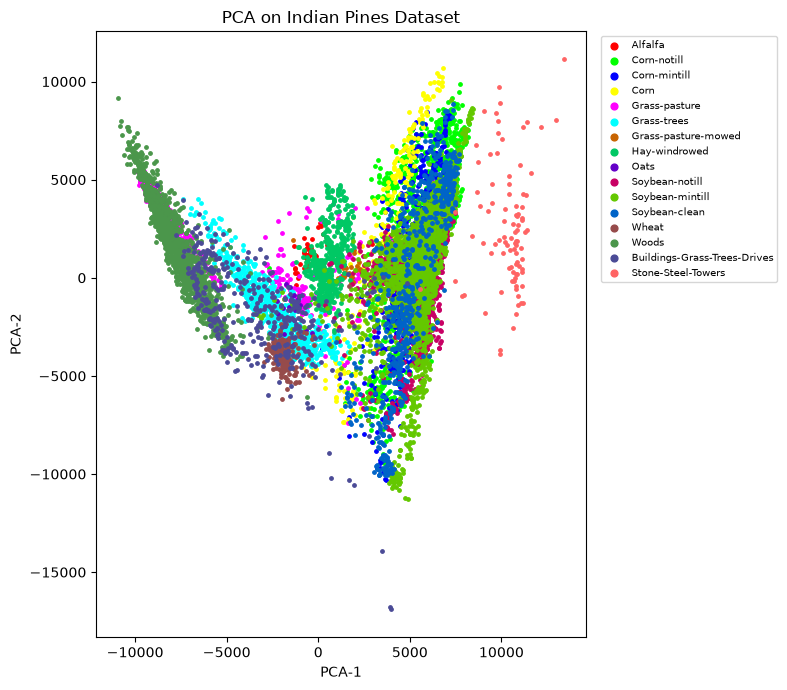

Explained variance ratio (PC1, PC2): [0.6849 0.2353]


In [13]:
# Flatten the cube to (pixels, bands) and run PCA on every pixel
H, W, B = X.shape
X2d = X.reshape(-1, B).astype(float)
gt_flat = gt.reshape(-1)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X2d)

colors = spy_colors / 255.0
labeled = gt_flat > 0
plt.figure(figsize=(8, 7))
for c in np.unique(gt_flat[labeled]):
    sel = gt_flat == c
    plt.scatter(X_pca[sel, 0], X_pca[sel, 1], s=6, color=colors[c], label=class_names[c])
plt.xlabel("PCA-1"); plt.ylabel("PCA-2")
plt.title("PCA on Indian Pines Dataset")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, markerscale=2)
plt.tight_layout()
plt.show()

print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 4))

#### 7.2. Apply t-SNE on the data cube and display the data scatter using the first two components

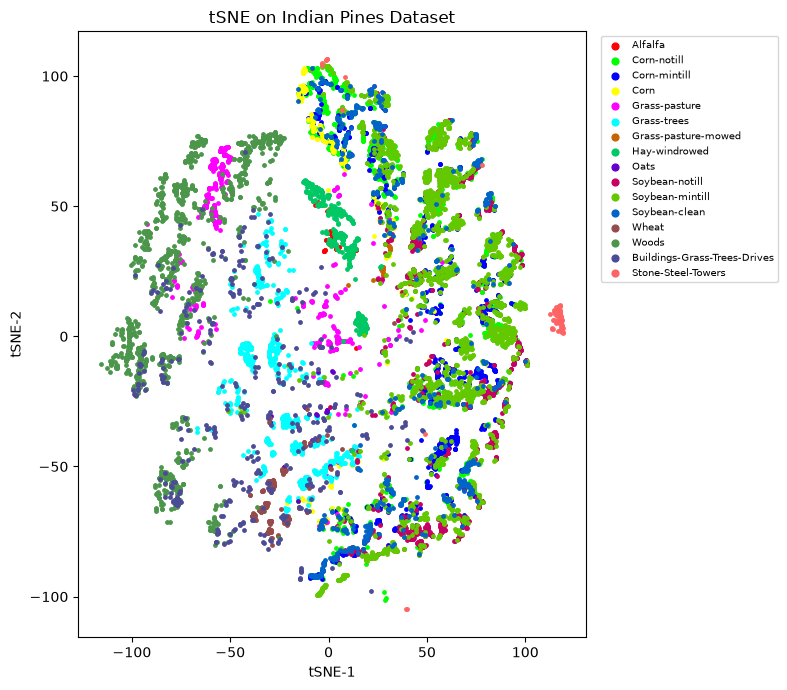

In [14]:
# t-SNE is heavy on 21,025 pixels, so reduce to 30 PCA dimensions first (standard practice)
X_pca30 = PCA(n_components=30, random_state=42).fit_transform(X2d)

tsne = TSNE(n_components=2, perplexity=30, init="pca",
            learning_rate="auto", random_state=42)
X_tsne = tsne.fit_transform(X_pca30)

plt.figure(figsize=(8, 7))
for c in np.unique(gt_flat[labeled]):
    sel = gt_flat == c
    plt.scatter(X_tsne[sel, 0], X_tsne[sel, 1], s=6, color=colors[c], label=class_names[c])
plt.xlabel("tSNE-1"); plt.ylabel("tSNE-2")
plt.title("tSNE on Indian Pines Dataset")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, markerscale=2)
plt.tight_layout()
plt.show()

#### 8.1.	Reconstruct the image using the first important component of PCA.

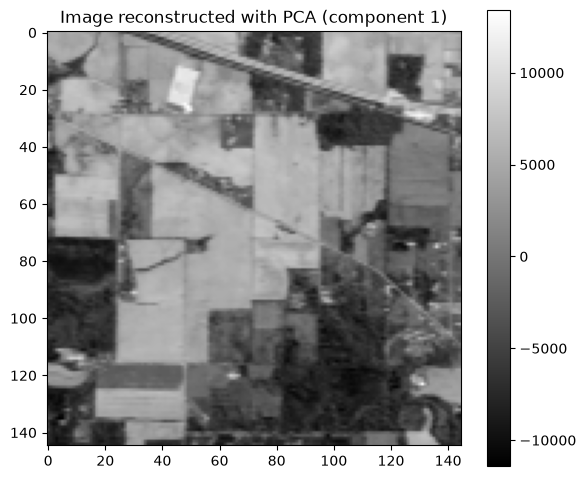

In [15]:
# The first principal component reshaped back to the 145x145 image grid
pc1_image = X_pca[:, 0].reshape(H, W)

plt.figure(figsize=(6, 6))
plt.imshow(pc1_image, cmap="gray")
plt.title("Image reconstructed with PCA (component 1)")
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.show()

#### 8.2. Reconstruct the image using the first important component of t-SNE.

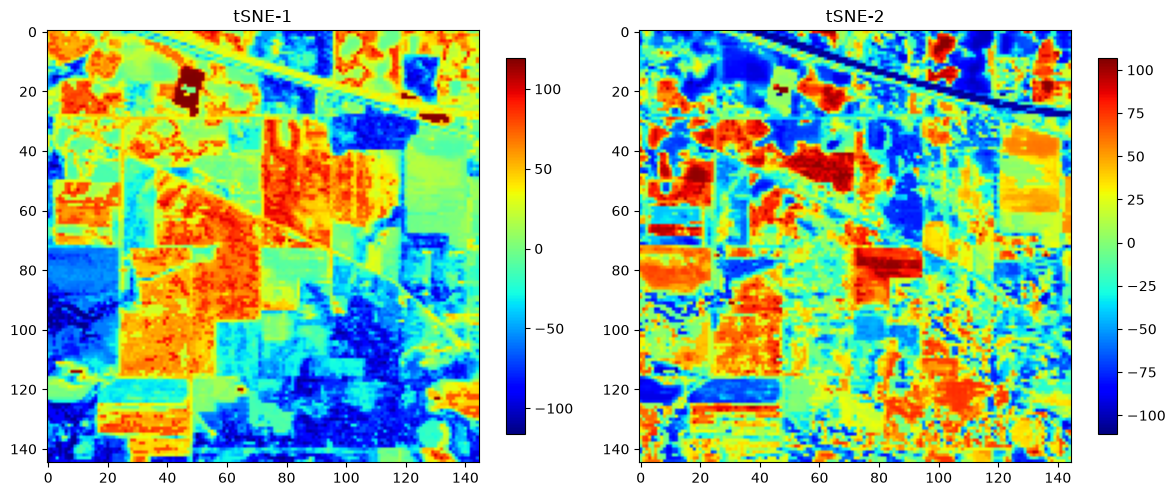

In [16]:
# Each t-SNE component reshaped back to the image grid
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, i, title in zip(axes, [0, 1], ["tSNE-1", "tSNE-2"]):
    im = ax.imshow(X_tsne[:, i].reshape(H, W), cmap="jet")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()